In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix
import cv2
import seaborn as sns
from pathlib import Path




ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
train_dir = '/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive/train'
val_dir = '/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive/val'
test_dir = '/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive/test'

In [ ]:
image_height = 224
image_width = 224
batch_size = 32


In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    color_mode = 'grayscale',
    image_size = (image_height, image_width),
    batch_size = batch_size
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    color_mode = 'grayscale',
    image_size = (image_height, image_width),
    batch_size = batch_size
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    color_mode = 'grayscale',
    image_size = (image_height, image_width),
    batch_size = batch_size
)

Found 20450 files belonging to 3 classes.
Found 2534 files belonging to 3 classes.
Found 2569 files belonging to 3 classes.


In [ ]:
train_ds.class_names

['normal', 'pneumonia', 'tuberculosis']

2025-11-13 18:28:19.811943: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


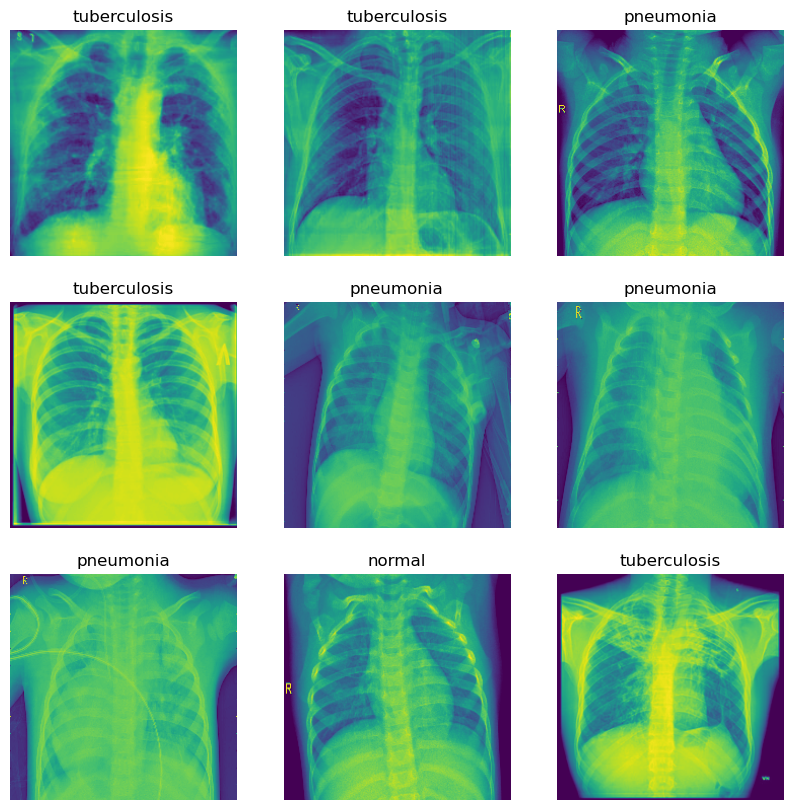

In [ ]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(np.squeeze(images[i].numpy().astype('uint8')))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis('off')

In [ ]:
autotune = tf.data. experimental.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = autotune)
val_ds = val_ds.cache().prefetch(buffer_size = autotune)
test_ds = test_ds.cache().prefetch(buffer_size = autotune)

In [ ]:
model = tf.keras.Sequential([
   tf.keras.layers.Rescaling(1./255), 
    tf.keras.layers.Conv2D(32, 3, activation = 'relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation = 'relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation = 'relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dense(4, activation = 'sigmoid')
])

In [ ]:
model.compile(optimizer = 'Adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics = ['accuracy'])

In [ ]:
epochs = 10

In [ ]:
model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = epochs
)

Epoch 1/10


: 